In [2]:
# Cell 1. Imports y rutas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter6"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter6"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 2. Cargar predicciones ML del Notebook 05 — MAIN y ROBUST

# MAIN
predictions_path_main = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions.csv"

if not predictions_path_main.exists():
    raise FileNotFoundError(f"No existe el archivo MAIN: {predictions_path_main}")

df_main = (
    pd.read_csv(predictions_path_main, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("MAIN")
print("Shape:", df_main.shape)
print("Rango fechas:", df_main["date"].min(), "->", df_main["date"].max())
print(df_main["sample_split_main"].value_counts(dropna=False))
display(df_main.head())


# ROBUST
predictions_path_robust = PROCESSED_DATA_DIR / "dataset_cap5_regime_predictions_robust.csv"

if not predictions_path_robust.exists():
    raise FileNotFoundError(f"No existe el archivo ROBUST: {predictions_path_robust}")

df_robust = (
    pd.read_csv(predictions_path_robust, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nROBUST")
print("Shape:", df_robust.shape)
print("Rango fechas:", df_robust["date"].min(), "->", df_robust["date"].max())
print(df_robust["sample_split_robust"].value_counts(dropna=False))
display(df_robust.head())

MAIN
Shape: (1356, 9)
Rango fechas: 2021-01-04 00:00:00 -> 2026-04-22 00:00:00
sample_split_main
test    1356
Name: count, dtype: int64


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2021-01-04,test,0.003153,2,0,2,0.031838,0.001202,0.966959
1,2021-01-05,test,-0.000951,0,2,2,0.070465,0.001171,0.928364
2,2021-01-06,test,0.031483,2,2,2,0.002664,0.002200,0.995135
3,2021-01-07,test,0.004242,2,2,2,0.008713,0.001886,0.989401
4,2021-01-08,test,0.002608,2,2,2,0.010411,0.002009,0.987580



ROBUST
Shape: (1613, 9)
Rango fechas: 2020-01-02 00:00:00 -> 2026-04-22 00:00:00
sample_split_robust
test    1613
Name: count, dtype: int64


,date,sample_split_robust,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2020-01-02,test,0.014761,0,0,0,0.970605,0.029381,0.000014
1,2020-01-03,test,-0.004613,0,0,0,0.975584,0.024402,0.000014
2,2020-01-06,test,-0.004749,0,0,0,0.977266,0.022720,0.000014
3,2020-01-07,test,-0.002200,0,0,0,0.978112,0.021874,0.000014
4,2020-01-08,test,0.001210,0,0,0,0.978584,0.021402,0.000014


In [4]:
# Cell 3. Validaciones mínimas — MAIN y ROBUST

# MAIN
required_cols_main = [
    "date",
    "sample_split_main",
    "ret_1d",
    "regime",
    "regime_t_plus_1",
    "regime_pred",
]

missing_cols_main = [col for col in required_cols_main if col not in df_main.columns]

if missing_cols_main:
    raise ValueError(f"MAIN - Faltan columnas obligatorias: {missing_cols_main}")

proba_cols_main = [col for col in df_main.columns if col.startswith("proba_")]

if not proba_cols_main:
    raise ValueError("MAIN - No se han encontrado columnas de probabilidades proba_")

print("MAIN - Columnas de probabilidad:", proba_cols_main)
print("MAIN - Validaciones OK")


# ROBUST
required_cols_robust = [
    "date",
    "sample_split_robust",
    "ret_1d",
    "regime",
    "regime_t_plus_1",
    "regime_pred",
]

missing_cols_robust = [col for col in required_cols_robust if col not in df_robust.columns]

if missing_cols_robust:
    raise ValueError(f"ROBUST - Faltan columnas obligatorias: {missing_cols_robust}")

proba_cols_robust = [col for col in df_robust.columns if col.startswith("proba_")]

if not proba_cols_robust:
    raise ValueError("ROBUST - No se han encontrado columnas de probabilidades proba_")

print("\nROBUST - Columnas de probabilidad:", proba_cols_robust)
print("ROBUST - Validaciones OK")

MAIN - Columnas de probabilidad: ['proba_0', 'proba_1', 'proba_2']
MAIN - Validaciones OK

ROBUST - Columnas de probabilidad: ['proba_0', 'proba_1', 'proba_2']
ROBUST - Validaciones OK


In [5]:
# Cell 4. Cargar mapping económico régimen → exposición — MAIN y ROBUST

# MAIN
mapping_path_main = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping.csv"

if not mapping_path_main.exists():
    raise FileNotFoundError(f"No existe el mapping MAIN: {mapping_path_main}")

regime_mapping_main = pd.read_csv(mapping_path_main)

required_map_cols = ["regime", "economic_label", "risk_order", "target_exposure"]
missing_map_cols_main = [col for col in required_map_cols if col not in regime_mapping_main.columns]

if missing_map_cols_main:
    raise ValueError(f"MAIN - Faltan columnas en mapping: {missing_map_cols_main}")

regime_mapping_main["regime"] = regime_mapping_main["regime"].astype(int)
regime_mapping_main["target_exposure"] = regime_mapping_main["target_exposure"].astype(float)

regime_exposure_map_main = dict(
    zip(regime_mapping_main["regime"], regime_mapping_main["target_exposure"])
)

print("MAIN mapping:")
display(regime_mapping_main)
print(regime_exposure_map_main)


# ROBUST
mapping_path_robust = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping_robust.csv"

if not mapping_path_robust.exists():
    raise FileNotFoundError(f"No existe el mapping ROBUST: {mapping_path_robust}")

regime_mapping_robust = pd.read_csv(mapping_path_robust)

missing_map_cols_robust = [col for col in required_map_cols if col not in regime_mapping_robust.columns]

if missing_map_cols_robust:
    raise ValueError(f"ROBUST - Faltan columnas en mapping: {missing_map_cols_robust}")

regime_mapping_robust["regime"] = regime_mapping_robust["regime"].astype(int)
regime_mapping_robust["target_exposure"] = regime_mapping_robust["target_exposure"].astype(float)

regime_exposure_map_robust = dict(
    zip(regime_mapping_robust["regime"], regime_mapping_robust["target_exposure"])
)

print("\nROBUST mapping:")
display(regime_mapping_robust)
print(regime_exposure_map_robust)

MAIN mapping:


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.00
1,2,medium_risk,2,0.75
2,1,high_risk,3,0.25


{0: 1.0, 2: 0.75, 1: 0.25}

ROBUST mapping:


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.00
1,1,medium_risk,2,0.75
2,2,high_risk,3,0.25


{0: 1.0, 1: 0.75, 2: 0.25}


In [6]:
# Cell 5. Filtrar periodo out-of-sample — MAIN y ROBUST

# MAIN
df_test_main = df_main[df_main["sample_split_main"] == "test"].copy()
df_test_main = df_test_main.sort_values("date").reset_index(drop=True)

if df_test_main.empty:
    raise ValueError("df_test_main está vacío.")

print("MAIN df_test shape:", df_test_main.shape)
print("MAIN rango:", df_test_main["date"].min(), "->", df_test_main["date"].max())
display(df_test_main.head())


# ROBUST
df_test_robust = df_robust[df_robust["sample_split_robust"] == "test"].copy()
df_test_robust = df_test_robust.sort_values("date").reset_index(drop=True)

if df_test_robust.empty:
    raise ValueError("df_test_robust está vacío.")

print("\nROBUST df_test shape:", df_test_robust.shape)
print("ROBUST rango:", df_test_robust["date"].min(), "->", df_test_robust["date"].max())
display(df_test_robust.head())

MAIN df_test shape: (1356, 9)
MAIN rango: 2021-01-04 00:00:00 -> 2026-04-22 00:00:00


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2021-01-04,test,0.003153,2,0,2,0.031838,0.001202,0.966959
1,2021-01-05,test,-0.000951,0,2,2,0.070465,0.001171,0.928364
2,2021-01-06,test,0.031483,2,2,2,0.002664,0.002200,0.995135
3,2021-01-07,test,0.004242,2,2,2,0.008713,0.001886,0.989401
4,2021-01-08,test,0.002608,2,2,2,0.010411,0.002009,0.987580



ROBUST df_test shape: (1613, 9)
ROBUST rango: 2020-01-02 00:00:00 -> 2026-04-22 00:00:00


,date,sample_split_robust,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2
0,2020-01-02,test,0.014761,0,0,0,0.970605,0.029381,0.000014
1,2020-01-03,test,-0.004613,0,0,0,0.975584,0.024402,0.000014
2,2020-01-06,test,-0.004749,0,0,0,0.977266,0.022720,0.000014
3,2020-01-07,test,-0.002200,0,0,0,0.978112,0.021874,0.000014
4,2020-01-08,test,0.001210,0,0,0,0.978584,0.021402,0.000014


In [7]:
# Cell 6. Validar cobertura del mapping — MAIN y ROBUST

# MAIN
predicted_regimes_main = set(df_test_main["regime_pred"].dropna().astype(int).unique())
mapped_regimes_main = set(regime_exposure_map_main.keys())

missing_main = predicted_regimes_main - mapped_regimes_main

if missing_main:
    raise ValueError(
        f"MAIN - Regímenes predichos sin mapping: {sorted(missing_main)}"
    )

print("MAIN - Regímenes predichos:", sorted(predicted_regimes_main))
print("MAIN - Mapping completo OK")


# ROBUST
predicted_regimes_robust = set(df_test_robust["regime_pred"].dropna().astype(int).unique())
mapped_regimes_robust = set(regime_exposure_map_robust.keys())

missing_robust = predicted_regimes_robust - mapped_regimes_robust

if missing_robust:
    raise ValueError(
        f"ROBUST - Regímenes predichos sin mapping: {sorted(missing_robust)}"
    )

print("\nROBUST - Regímenes predichos:", sorted(predicted_regimes_robust))
print("ROBUST - Mapping completo OK")

MAIN - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
MAIN - Mapping completo OK

ROBUST - Regímenes predichos: [np.int64(0), np.int64(1), np.int64(2)]
ROBUST - Mapping completo OK


In [8]:
# Cell 7. Estrategia ML hard classification — MAIN y ROBUST

df_test_main["target_exposure_ml_hard"] = (
    df_test_main["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_main)
)

if df_test_main["target_exposure_ml_hard"].isna().any():
    missing = sorted(
        df_test_main.loc[df_test_main["target_exposure_ml_hard"].isna(), "regime_pred"]
        .dropna()
        .unique()
    )
    raise ValueError(f"MAIN - Regímenes predichos sin exposición hard: {missing}")

print("MAIN - Exposición hard:")
print(df_test_main["target_exposure_ml_hard"].describe())


df_test_robust["target_exposure_ml_hard"] = (
    df_test_robust["regime_pred"]
    .astype(int)
    .map(regime_exposure_map_robust)
)

if df_test_robust["target_exposure_ml_hard"].isna().any():
    missing = sorted(
        df_test_robust.loc[df_test_robust["target_exposure_ml_hard"].isna(), "regime_pred"]
        .dropna()
        .unique()
    )
    raise ValueError(f"ROBUST - Regímenes predichos sin exposición hard: {missing}")

print("\nROBUST - Exposición hard:")
print(df_test_robust["target_exposure_ml_hard"].describe())

MAIN - Exposición hard:
count    1356.000000
mean        0.910029
std         0.140239
min         0.250000
25%         0.750000
50%         1.000000
75%         1.000000
max         1.000000
Name: target_exposure_ml_hard, dtype: float64

ROBUST - Exposición hard:
count    1613.000000
mean        0.862678
std         0.211646
min         0.250000
25%         0.750000
50%         1.000000
75%         1.000000
max         1.000000
Name: target_exposure_ml_hard, dtype: float64


In [9]:
# Cell 8. Estrategia ML probability-weighted — MAIN y ROBUST

# MAIN
for regime in regime_exposure_map_main:
    col = f"proba_{regime}"
    if col not in df_test_main.columns:
        raise ValueError(f"MAIN - Falta columna de probabilidad para régimen {regime}: {col}")

df_test_main["target_exposure_ml_proba"] = 0.0

for regime, exposure in regime_exposure_map_main.items():
    df_test_main["target_exposure_ml_proba"] += (
        df_test_main[f"proba_{regime}"] * exposure
    )

if df_test_main["target_exposure_ml_proba"].isna().any():
    raise ValueError("MAIN - Hay valores nulos en target_exposure_ml_proba.")

if not df_test_main["target_exposure_ml_proba"].between(0, 1).all():
    raise ValueError("MAIN - target_exposure_ml_proba fuera del rango [0, 1].")

print("MAIN - Exposición probabilística:")
print(df_test_main["target_exposure_ml_proba"].describe())


# ROBUST
for regime in regime_exposure_map_robust:
    col = f"proba_{regime}"
    if col not in df_test_robust.columns:
        raise ValueError(f"ROBUST - Falta columna de probabilidad para régimen {regime}: {col}")

df_test_robust["target_exposure_ml_proba"] = 0.0

for regime, exposure in regime_exposure_map_robust.items():
    df_test_robust["target_exposure_ml_proba"] += (
        df_test_robust[f"proba_{regime}"] * exposure
    )

if df_test_robust["target_exposure_ml_proba"].isna().any():
    raise ValueError("ROBUST - Hay valores nulos en target_exposure_ml_proba.")

if not df_test_robust["target_exposure_ml_proba"].between(0, 1).all():
    raise ValueError("ROBUST - target_exposure_ml_proba fuera del rango [0, 1].")

print("\nROBUST - Exposición probabilística:")
print(df_test_robust["target_exposure_ml_proba"].describe())

MAIN - Exposición probabilística:
count    1356.000000
mean        0.903063
std         0.123784
min         0.253596
25%         0.795481
50%         0.974724
75%         0.992625
max         0.998601
Name: target_exposure_ml_proba, dtype: float64

ROBUST - Exposición probabilística:
count    1613.000000
mean        0.851979
std         0.181491
min         0.270849
25%         0.762555
50%         0.936476
75%         0.985564
max         0.994685
Name: target_exposure_ml_proba, dtype: float64


In [10]:
# Cell 9. Aplicar shift operativo para evitar look-ahead — MAIN y ROBUST

# MAIN
df_test_main["strategy_exposure_ml_hard"] = df_test_main["target_exposure_ml_hard"].shift(1)
df_test_main["strategy_exposure_ml_proba"] = df_test_main["target_exposure_ml_proba"].shift(1)

df_test_bt_main = df_test_main.dropna(
    subset=[
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
    ]
).copy()

if df_test_bt_main.empty:
    raise ValueError("MAIN - df_test_bt está vacío tras shift(1).")

print("MAIN df_test_bt shape:", df_test_bt_main.shape)

display(
    df_test_bt_main[
        [
            "date",
            "ret_1d",
            "regime",
            "regime_t_plus_1",
            "regime_pred",
            "target_exposure_ml_hard",
            "target_exposure_ml_proba",
            "strategy_exposure_ml_hard",
            "strategy_exposure_ml_proba",
        ]
    ].head()
)


# ROBUST
df_test_robust["strategy_exposure_ml_hard"] = df_test_robust["target_exposure_ml_hard"].shift(1)
df_test_robust["strategy_exposure_ml_proba"] = df_test_robust["target_exposure_ml_proba"].shift(1)

df_test_bt_robust = df_test_robust.dropna(
    subset=[
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
    ]
).copy()

if df_test_bt_robust.empty:
    raise ValueError("ROBUST - df_test_bt está vacío tras shift(1).")

print("\nROBUST df_test_bt shape:", df_test_bt_robust.shape)

display(
    df_test_bt_robust[
        [
            "date",
            "ret_1d",
            "regime",
            "regime_t_plus_1",
            "regime_pred",
            "target_exposure_ml_hard",
            "target_exposure_ml_proba",
            "strategy_exposure_ml_hard",
            "strategy_exposure_ml_proba",
        ]
    ].head()
)

MAIN df_test_bt shape: (1355, 13)


,date,ret_1d,regime,regime_t_plus_1,regime_pred,target_exposure_ml_hard,target_exposure_ml_proba,strategy_exposure_ml_hard,strategy_exposure_ml_proba
1,2021-01-05,-0.000951,0,2,2,0.75,0.767031,0.75,0.757358
2,2021-01-06,0.031483,2,2,2,0.75,0.749566,0.75,0.767031
3,2021-01-07,0.004242,2,2,2,0.75,0.751235,0.75,0.749566
4,2021-01-08,0.002608,2,2,2,0.75,0.751598,0.75,0.751235
5,2021-01-11,-0.005989,2,2,2,0.75,0.754102,0.75,0.751598



ROBUST df_test_bt shape: (1612, 13)


,date,ret_1d,regime,regime_t_plus_1,regime_pred,target_exposure_ml_hard,target_exposure_ml_proba,strategy_exposure_ml_hard,strategy_exposure_ml_proba
1,2020-01-03,-0.004613,0,0,0,1.0,0.993889,1.0,0.992644
2,2020-01-06,-0.004749,0,0,0,1.0,0.994310,1.0,0.993889
3,2020-01-07,-0.002200,0,0,0,1.0,0.994521,1.0,0.994310
4,2020-01-08,0.001210,0,0,0,1.0,0.994639,1.0,0.994521
5,2020-01-09,-0.001001,0,0,0,1.0,0.994632,1.0,0.994639


In [11]:
# Cell 10. Construir retornos de benchmark y estrategias ML — MAIN y ROBUST

# MAIN
df_test_bt_main["benchmark_return"] = df_test_bt_main["ret_1d"]

df_test_bt_main["ml_hard_return"] = (
    df_test_bt_main["strategy_exposure_ml_hard"] * df_test_bt_main["ret_1d"]
)

df_test_bt_main["ml_proba_return"] = (
    df_test_bt_main["strategy_exposure_ml_proba"] * df_test_bt_main["ret_1d"]
)

df_test_bt_main["benchmark_cum"] = np.exp(df_test_bt_main["benchmark_return"].cumsum())
df_test_bt_main["ml_hard_cum"] = np.exp(df_test_bt_main["ml_hard_return"].cumsum())
df_test_bt_main["ml_proba_cum"] = np.exp(df_test_bt_main["ml_proba_return"].cumsum())

print("MAIN retornos OK")
display(
    df_test_bt_main[
        [
            "date",
            "benchmark_return",
            "ml_hard_return",
            "ml_proba_return",
            "benchmark_cum",
            "ml_hard_cum",
            "ml_proba_cum",
        ]
    ].head()
)


# ROBUST
df_test_bt_robust["benchmark_return"] = df_test_bt_robust["ret_1d"]

df_test_bt_robust["ml_hard_return"] = (
    df_test_bt_robust["strategy_exposure_ml_hard"] * df_test_bt_robust["ret_1d"]
)

df_test_bt_robust["ml_proba_return"] = (
    df_test_bt_robust["strategy_exposure_ml_proba"] * df_test_bt_robust["ret_1d"]
)

df_test_bt_robust["benchmark_cum"] = np.exp(df_test_bt_robust["benchmark_return"].cumsum())
df_test_bt_robust["ml_hard_cum"] = np.exp(df_test_bt_robust["ml_hard_return"].cumsum())
df_test_bt_robust["ml_proba_cum"] = np.exp(df_test_bt_robust["ml_proba_return"].cumsum())

print("\nROBUST retornos OK")
display(
    df_test_bt_robust[
        [
            "date",
            "benchmark_return",
            "ml_hard_return",
            "ml_proba_return",
            "benchmark_cum",
            "ml_hard_cum",
            "ml_proba_cum",
        ]
    ].head()
)

MAIN retornos OK


,date,benchmark_return,ml_hard_return,ml_proba_return,benchmark_cum,ml_hard_cum,ml_proba_cum
1,2021-01-05,-0.000951,-0.000713,-0.000720,0.999049,0.999287,0.999280
2,2021-01-06,0.031483,0.023612,0.024149,1.031003,1.023163,1.023705
3,2021-01-07,0.004242,0.003182,0.003180,1.035386,1.026424,1.026965
4,2021-01-08,0.002608,0.001956,0.001959,1.038090,1.028434,1.028980
5,2021-01-11,-0.005989,-0.004491,-0.004501,1.031892,1.023825,1.024358



ROBUST retornos OK


,date,benchmark_return,ml_hard_return,ml_proba_return,benchmark_cum,ml_hard_cum,ml_proba_cum
1,2020-01-03,-0.004613,-0.004613,-0.004579,0.995398,0.995398,0.995432
2,2020-01-06,-0.004749,-0.004749,-0.004720,0.990682,0.990682,0.990745
3,2020-01-07,-0.002200,-0.002200,-0.002188,0.988505,0.988505,0.988580
4,2020-01-08,0.001210,0.001210,0.001204,0.989702,0.989702,0.989770
5,2020-01-09,-0.001001,-0.001001,-0.000996,0.988711,0.988711,0.988785


In [12]:
# Cell 11. Funciones de métricas

def compute_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    return cumulative_returns / running_max - 1


def historical_var(returns, alpha=0.95):
    return returns.quantile(1 - alpha)


def historical_cvar(returns, alpha=0.95):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()


def summarize_strategy(strategy_name, returns, cumulative_returns):
    drawdown = compute_drawdown(cumulative_returns)

    return {
        "strategy": strategy_name,
        "total_return": cumulative_returns.iloc[-1] - 1,
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "VaR_95": historical_var(returns),
        "CVaR_95": historical_cvar(returns),
        "max_drawdown": drawdown.min(),
    }

In [13]:
# Cell 12. Calcular métricas OOS — MAIN y ROBUST

# MAIN
metrics_ml_main = pd.DataFrame(
    [
        summarize_strategy(
            "Buy & Hold",
            df_test_bt_main["benchmark_return"],
            df_test_bt_main["benchmark_cum"],
        ),
        summarize_strategy(
            "ML hard classification",
            df_test_bt_main["ml_hard_return"],
            df_test_bt_main["ml_hard_cum"],
        ),
        summarize_strategy(
            "ML probability-weighted",
            df_test_bt_main["ml_proba_return"],
            df_test_bt_main["ml_proba_cum"],
        ),
    ]
)

print("MAIN metrics:")
display(metrics_ml_main)


# ROBUST
metrics_ml_robust = pd.DataFrame(
    [
        summarize_strategy(
            "Buy & Hold",
            df_test_bt_robust["benchmark_return"],
            df_test_bt_robust["benchmark_cum"],
        ),
        summarize_strategy(
            "ML hard classification",
            df_test_bt_robust["ml_hard_return"],
            df_test_bt_robust["ml_hard_cum"],
        ),
        summarize_strategy(
            "ML probability-weighted",
            df_test_bt_robust["ml_proba_return"],
            df_test_bt_robust["ml_proba_cum"],
        ),
    ]
)

print("\nROBUST metrics:")
display(metrics_ml_robust)

MAIN metrics:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.223232,0.000590,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.890491,0.000470,0.008788,-0.014179,-0.020518,-0.230939
2,ML probability-weighted,0.855749,0.000456,0.008725,-0.014109,-0.020348,-0.229311



ROBUST metrics:


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.858016,0.000384,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.615060,0.000297,0.009093,-0.014869,-0.021838,-0.261592
2,ML probability-weighted,0.639081,0.000307,0.009048,-0.014611,-0.021731,-0.251019


In [14]:
# Cell 13. Drawdowns — MAIN y ROBUST

# MAIN
df_test_bt_main["benchmark_drawdown"] = compute_drawdown(df_test_bt_main["benchmark_cum"])
df_test_bt_main["ml_hard_drawdown"] = compute_drawdown(df_test_bt_main["ml_hard_cum"])
df_test_bt_main["ml_proba_drawdown"] = compute_drawdown(df_test_bt_main["ml_proba_cum"])

print("MAIN drawdowns:")
display(
    df_test_bt_main[
        [
            "date",
            "benchmark_drawdown",
            "ml_hard_drawdown",
            "ml_proba_drawdown",
        ]
    ].head()
)


# ROBUST
df_test_bt_robust["benchmark_drawdown"] = compute_drawdown(df_test_bt_robust["benchmark_cum"])
df_test_bt_robust["ml_hard_drawdown"] = compute_drawdown(df_test_bt_robust["ml_hard_cum"])
df_test_bt_robust["ml_proba_drawdown"] = compute_drawdown(df_test_bt_robust["ml_proba_cum"])

print("\nROBUST drawdowns:")
display(
    df_test_bt_robust[
        [
            "date",
            "benchmark_drawdown",
            "ml_hard_drawdown",
            "ml_proba_drawdown",
        ]
    ].head()
)

MAIN drawdowns:


,date,benchmark_drawdown,ml_hard_drawdown,ml_proba_drawdown
1,2021-01-05,0.000000,0.000000,0.000000
2,2021-01-06,0.000000,0.000000,0.000000
3,2021-01-07,0.000000,0.000000,0.000000
4,2021-01-08,0.000000,0.000000,0.000000
5,2021-01-11,-0.005971,-0.004481,-0.004491



ROBUST drawdowns:


,date,benchmark_drawdown,ml_hard_drawdown,ml_proba_drawdown
1,2020-01-03,0.000000,0.000000,0.000000
2,2020-01-06,-0.004737,-0.004737,-0.004708
3,2020-01-07,-0.006925,-0.006925,-0.006883
4,2020-01-08,-0.005722,-0.005722,-0.005687
5,2020-01-09,-0.006717,-0.006717,-0.006677


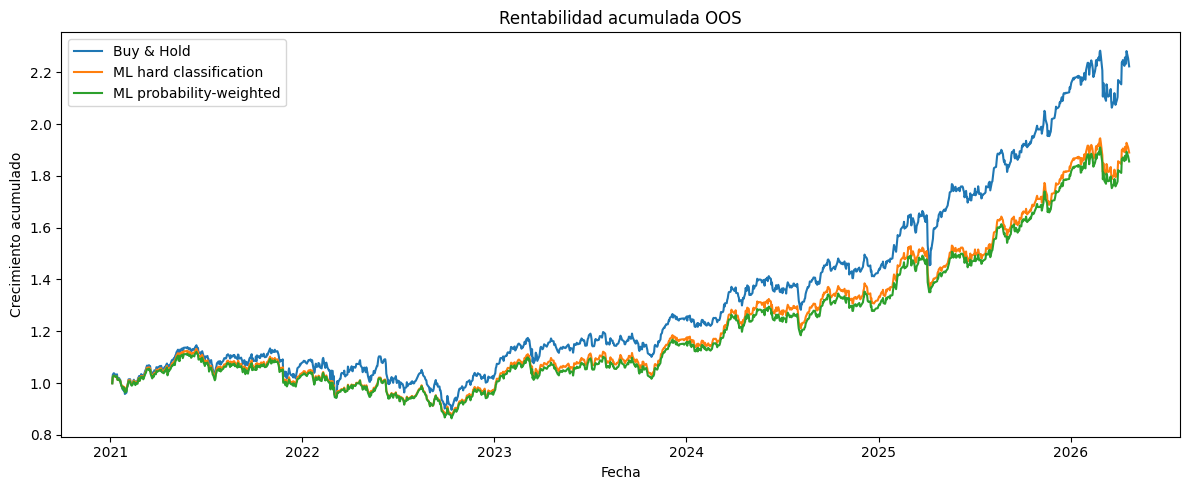

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ml_oos_cumulative_returns.png


In [14]:
# Cell 14. Gráfico de rentabilidad acumulada

plt.figure(figsize=(12, 5))

plt.plot(
    df_test_bt["date"],
    df_test_bt["benchmark_cum"],
    label="Buy & Hold",
)

plt.plot(
    df_test_bt["date"],
    df_test_bt["ml_hard_cum"],
    label="ML hard classification",
)

plt.plot(
    df_test_bt["date"],
    df_test_bt["ml_proba_cum"],
    label="ML probability-weighted",
)

plt.title("Rentabilidad acumulada OOS")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento acumulado")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "ml_oos_cumulative_returns.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path)


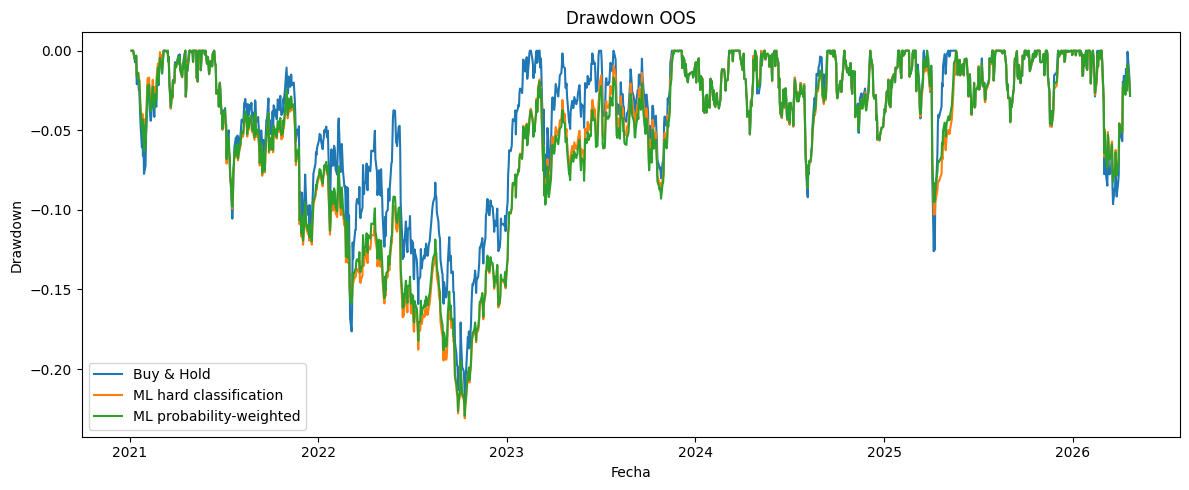

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ml_oos_drawdown.png


In [15]:
# Cell 15. Gráfico de drawdown — MAIN

plt.figure(figsize=(12, 5))

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["benchmark_drawdown"],
    label="Buy & Hold",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_hard_drawdown"],
    label="ML hard classification",
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_proba_drawdown"],
    label="ML probability-weighted",
)

plt.title("Drawdown OOS")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "ml_oos_drawdown.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path)

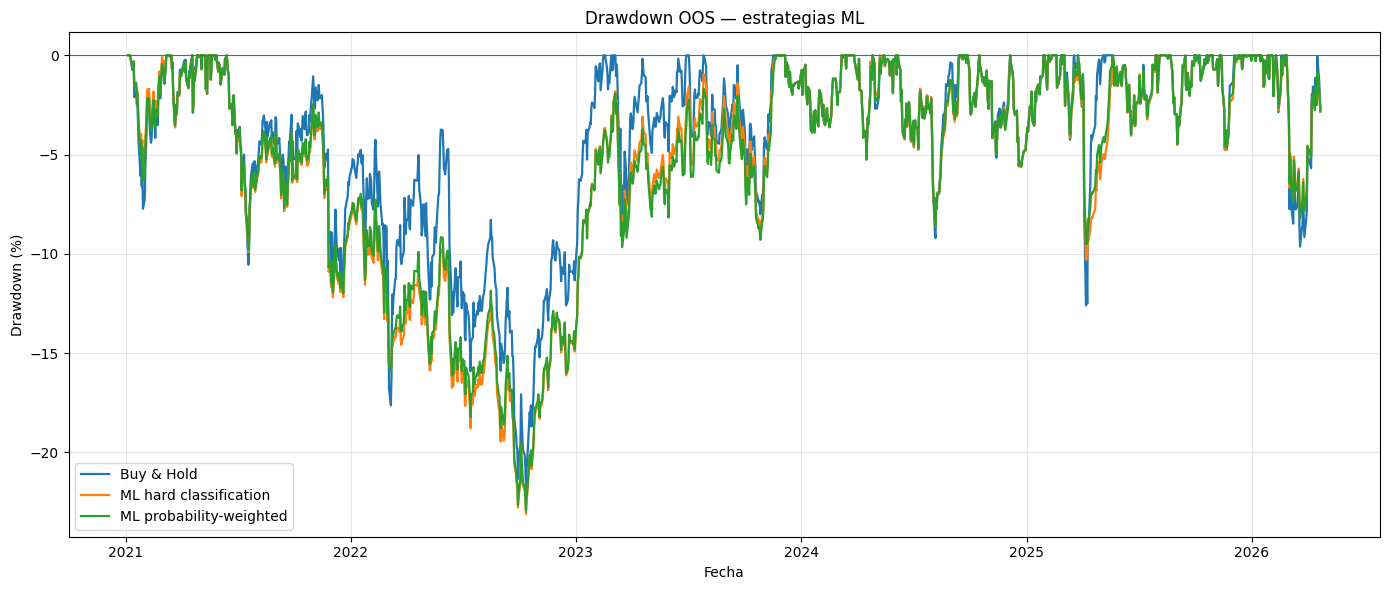

Figura guardada: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ml_oos_drawdown.png


In [16]:
# Cell 15. Gráfico de drawdown — MAIN mejorado

plt.figure(figsize=(14, 6))

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["benchmark_drawdown"] * 100,
    label="Buy & Hold",
    linewidth=1.6,
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_hard_drawdown"] * 100,
    label="ML hard classification",
    linewidth=1.6,
)

plt.plot(
    df_test_bt_main["date"],
    df_test_bt_main["ml_proba_drawdown"] * 100,
    label="ML probability-weighted",
    linewidth=1.6,
)

plt.axhline(0, linewidth=0.8)

plt.title("Drawdown OOS — estrategias ML")
plt.xlabel("Fecha")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "ml_oos_drawdown.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada:", fig_path)

In [17]:
# Cell 17. Comparación de riesgo extremo — MAIN y ROBUST

# MAIN
risk_comparison_main = metrics_ml_main[
    [
        "strategy",
        "daily_volatility",
        "VaR_95",
        "CVaR_95",
        "max_drawdown",
    ]
].copy()

print("MAIN - Comparación de riesgo extremo:")
display(risk_comparison_main)


# ROBUST
risk_comparison_robust = metrics_ml_robust[
    [
        "strategy",
        "daily_volatility",
        "VaR_95",
        "CVaR_95",
        "max_drawdown",
    ]
].copy()

print("\nROBUST - Comparación de riesgo extremo:")
display(risk_comparison_robust)

MAIN - Comparación de riesgo extremo:


,strategy,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.008788,-0.014179,-0.020518,-0.230939
2,ML probability-weighted,0.008725,-0.014109,-0.020348,-0.229311



ROBUST - Comparación de riesgo extremo:


,strategy,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.009093,-0.014869,-0.021838,-0.261592
2,ML probability-weighted,0.009048,-0.014611,-0.021731,-0.251019


In [18]:
# Cell 18. Validaciones finales — MAIN y ROBUST

# MAIN
if df_test_bt_main[["benchmark_return", "ml_hard_return", "ml_proba_return"]].isna().any().any():
    raise ValueError("MAIN - Hay NaNs en los retornos del backtest.")

if df_test_bt_main[["benchmark_cum", "ml_hard_cum", "ml_proba_cum"]].isna().any().any():
    raise ValueError("MAIN - Hay NaNs en los acumulados del backtest.")

expected_rows_main = len(df_test_main) - 1

if len(df_test_bt_main) != expected_rows_main:
    raise ValueError(
        f"MAIN - df_test_bt_main debería tener {expected_rows_main} filas tras shift(1), "
        f"pero tiene {len(df_test_bt_main)}."
    )

print("Validaciones finales MAIN OK")
print("df_test_main:", df_test_main.shape)
print("df_test_bt_main:", df_test_bt_main.shape)


# ROBUST
if df_test_bt_robust[["benchmark_return", "ml_hard_return", "ml_proba_return"]].isna().any().any():
    raise ValueError("ROBUST - Hay NaNs en los retornos del backtest.")

if df_test_bt_robust[["benchmark_cum", "ml_hard_cum", "ml_proba_cum"]].isna().any().any():
    raise ValueError("ROBUST - Hay NaNs en los acumulados del backtest.")

expected_rows_robust = len(df_test_robust) - 1

if len(df_test_bt_robust) != expected_rows_robust:
    raise ValueError(
        f"ROBUST - df_test_bt_robust debería tener {expected_rows_robust} filas tras shift(1), "
        f"pero tiene {len(df_test_bt_robust)}."
    )

print("\nValidaciones finales ROBUST OK")
print("df_test_robust:", df_test_robust.shape)
print("df_test_bt_robust:", df_test_bt_robust.shape)

Validaciones finales MAIN OK
df_test_main: (1356, 13)
df_test_bt_main: (1355, 22)

Validaciones finales ROBUST OK
df_test_robust: (1613, 13)
df_test_bt_robust: (1612, 22)


In [19]:
# Cell 19. Exportar resultados — MAIN y ROBUST

# MAIN
results_path_main = PROCESSED_DATA_DIR / "backtest_ml_results.csv"
metrics_path_main = TABLES_DIR / "ml_performance_metrics.csv"
risk_path_main = TABLES_DIR / "ml_risk_comparison.csv"

df_test_bt_main.to_csv(results_path_main, index=False)
metrics_ml_main.to_csv(metrics_path_main, index=False)
risk_comparison_main.to_csv(risk_path_main, index=False)

print("Exportado MAIN:", results_path_main)
print("Exportado MAIN:", metrics_path_main)
print("Exportado MAIN:", risk_path_main)


# ROBUST
results_path_robust = PROCESSED_DATA_DIR / "backtest_ml_results_robust.csv"
metrics_path_robust = TABLES_DIR / "ml_performance_metrics_robust.csv"
risk_path_robust = TABLES_DIR / "ml_risk_comparison_robust.csv"

df_test_bt_robust.to_csv(results_path_robust, index=False)
metrics_ml_robust.to_csv(metrics_path_robust, index=False)
risk_comparison_robust.to_csv(risk_path_robust, index=False)

print("\nExportado ROBUST:", results_path_robust)
print("Exportado ROBUST:", metrics_path_robust)
print("Exportado ROBUST:", risk_path_robust)

Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_ml_results.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_performance_metrics.csv
Exportado MAIN: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_risk_comparison.csv

Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_ml_results_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_performance_metrics_robust.csv
Exportado ROBUST: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ml_risk_comparison_robust.csv


In [20]:
# Cell 20. Resumen final — MAIN y ROBUST

print("Notebook 06 completado")

print("\nMAIN")
print("Observaciones OOS:", df_test_bt_main.shape[0])
print("Fecha inicio:", df_test_bt_main["date"].min())
print("Fecha fin:", df_test_bt_main["date"].max())
display(metrics_ml_main)

print("\nROBUST")
print("Observaciones OOS:", df_test_bt_robust.shape[0])
print("Fecha inicio:", df_test_bt_robust["date"].min())
print("Fecha fin:", df_test_bt_robust["date"].max())
display(metrics_ml_robust)

Notebook 06 completado

MAIN
Observaciones OOS: 1355
Fecha inicio: 2021-01-05 00:00:00
Fecha fin: 2026-04-22 00:00:00


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.223232,0.000590,0.010258,-0.015877,-0.023772,-0.217647
1,ML hard classification,0.890491,0.000470,0.008788,-0.014179,-0.020518,-0.230939
2,ML probability-weighted,0.855749,0.000456,0.008725,-0.014109,-0.020348,-0.229311



ROBUST
Observaciones OOS: 1612
Fecha inicio: 2020-01-03 00:00:00
Fecha fin: 2026-04-22 00:00:00


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,0.858016,0.000384,0.012733,-0.017651,-0.030660,-0.394343
1,ML hard classification,0.615060,0.000297,0.009093,-0.014869,-0.021838,-0.261592
2,ML probability-weighted,0.639081,0.000307,0.009048,-0.014611,-0.021731,-0.251019


## Resultados del backtest con estrategias basadas en Machine Learning

Se evalúan tres estrategias en out-of-sample:

- Buy & Hold (benchmark)
- ML hard classification (exposición discreta por régimen)
- ML probability-weighted (exposición continua basada en probabilidades)

El análisis se realiza bajo dos particiones:

- **MAIN** → train hasta 2020, test desde 2021  
- **ROBUST** → train hasta 2019, test desde 2020 (incluye COVID)

---

## Resultados en MAIN

En el escenario MAIN se observa un patrón claro:

- La estrategia ML reduce de forma consistente el riesgo:
  - Menor volatilidad diaria  
  - Mejores niveles de VaR y CVaR  
- Sin embargo, la rentabilidad acumulada es inferior al benchmark  
- El drawdown no mejora de forma significativa

En concreto:

- Volatilidad: ↓ ~15%  
- CVaR: mejora relevante  
- Rentabilidad: ↓ (1.22 → ~0.86)  
- Drawdown: ligeramente peor en ML  

Interpretación:

La estrategia actúa como un mecanismo de **reducción de exposición en fases de incertidumbre**, lo que limita pérdidas extremas pero también reduce la participación en mercados alcistas.

---

## Resultados en ROBUST

Cuando se incluye el periodo 2020 en test, los resultados cambian de forma importante:

- La reducción de riesgo se mantiene:
  - Volatilidad claramente menor  
  - Mejora significativa en VaR y CVaR  
- Aparece una mejora clara en drawdown:
  - Buy & Hold: -39.4%  
  - ML: ~ -25%  
- La rentabilidad sigue siendo inferior

Interpretación:

En entornos de estrés real, la estrategia ML:

- Reduce exposición antes o durante caídas fuertes  
- Evita pérdidas extremas prolongadas  
- Mejora de forma clara la protección de capital  

---

## Comparación MAIN vs ROBUST

La diferencia clave entre ambos escenarios es:

- **MAIN** no incluye una crisis extrema en test  
- **ROBUST** sí incluye el shock de 2020  

Esto provoca que:

- En MAIN → la estrategia parece conservadora pero no especialmente útil  
- En ROBUST → la estrategia muestra su verdadero valor como herramienta de gestión del riesgo extremo  

En otras palabras:

- El modelo no está diseñado para maximizar retornos  
- Está diseñado para **proteger en colas de distribución**

---

## Hard vs Probability-weighted

Entre las dos variantes ML:

- La estrategia probability-weighted:
  - Tiene comportamiento más suave  
  - Reduce ligeramente más el riesgo  
  - Evita cambios bruscos de exposición  
- La estrategia hard:
  - Es más agresiva  
  - Genera mayor rotación implícita  

Las diferencias son pequeñas, pero consistentes a favor del enfoque probabilístico.

---

## Conclusión

Los resultados permiten afirmar que:

- La estrategia basada en regímenes:
  - Reduce volatilidad  
  - Reduce riesgo extremo (VaR y CVaR)  
  - Mejora el comportamiento en crisis (drawdown en ROBUST)  
- A cambio:
  - Reduce la rentabilidad acumulada  

Esto es coherente con el objetivo del modelo:

> No maximizar retornos, sino mejorar la gestión del riesgo extremo mediante una asignación adaptativa basada en el estado del mercado.